<a href="https://colab.research.google.com/github/koushik1904/ML_assignments/blob/main/ML_assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 8: L1 Regularization -Lasso: Implementing Lasso Regression using libraries and
comparing results with Linear Regression.
Kaggle Dataset Link:
https://www.kaggle.com/datasets/debajyotipodder/co2-emission-by-vehicles
Tasks:
1. Load dataset and select features:
Engine Size, Cylinders, Fuel Consumption
Target: CO2 Emissions
2. Apply StandardScaler.
3. Train Linear Regression and Lasso Regression.
4. Use Ridge with multiple alpha values and find best alpha using:
GridSearchCV
5. Report best model performance and compare with Linear Regression.


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# Load dataset
file_path = "/content/CO2 Emissions_Canada.csv"
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
df.head()

Dataset Shape: (7385, 12)

Columns:
 Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='object')


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [3]:
# Selecting required features
features = ["Engine Size(L)",
            "Cylinders",
            "Fuel Consumption Comb (L/100 km)"]

target = "CO2 Emissions(g/km)"

X = df[features]
y = df[target]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (7385, 3)
Target Shape: (7385,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (5908, 3)
Testing Data Shape: (1477, 3)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standard Scaling Applied Successfully")

Standard Scaling Applied Successfully


In [6]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Results")
print("R2 Score :", round(r2_lr, 4))
print("RMSE     :", round(rmse_lr, 4))

Linear Regression Results
R2 Score : 0.8773
RMSE     : 20.5407


In [7]:
lasso = Lasso(alpha=0.01)   # Small alpha value
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Lasso Regression Results")
print("R2 Score :", round(r2_lasso, 4))
print("RMSE     :", round(rmse_lasso, 4))

Lasso Regression Results
R2 Score : 0.8773
RMSE     : 20.5409


In [8]:
ridge = Ridge()

param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]
}

grid = GridSearchCV(ridge, param_grid, cv=5, scoring="r2")
grid.fit(X_train_scaled, y_train)

best_alpha = grid.best_params_["alpha"]
best_ridge = grid.best_estimator_

y_pred_ridge = best_ridge.predict(X_test_scaled)

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge Regression Results")
print("Best Alpha :", best_alpha)
print("R2 Score   :", round(r2_ridge, 4))
print("RMSE       :", round(rmse_ridge, 4))

Ridge Regression Results
Best Alpha : 10
R2 Score   : 0.8773
RMSE       : 20.5414


In [9]:
print("\n===== MODEL COMPARISON =====")

print("Linear Regression  -> R2:", round(r2_lr,4), "| RMSE:", round(rmse_lr,4))
print("Lasso Regression   -> R2:", round(r2_lasso,4), "| RMSE:", round(rmse_lasso,4))
print("Ridge Regression   -> R2:", round(r2_ridge,4), "| RMSE:", round(rmse_ridge,4))

best_model = max(
    [("Linear Regression", r2_lr),
     ("Lasso Regression", r2_lasso),
     ("Ridge Regression", r2_ridge)],
    key=lambda x: x[1]
)

print("\nBest Model Based on R2 Score:", best_model[0])


===== MODEL COMPARISON =====
Linear Regression  -> R2: 0.8773 | RMSE: 20.5407
Lasso Regression   -> R2: 0.8773 | RMSE: 20.5409
Ridge Regression   -> R2: 0.8773 | RMSE: 20.5414

Best Model Based on R2 Score: Linear Regression


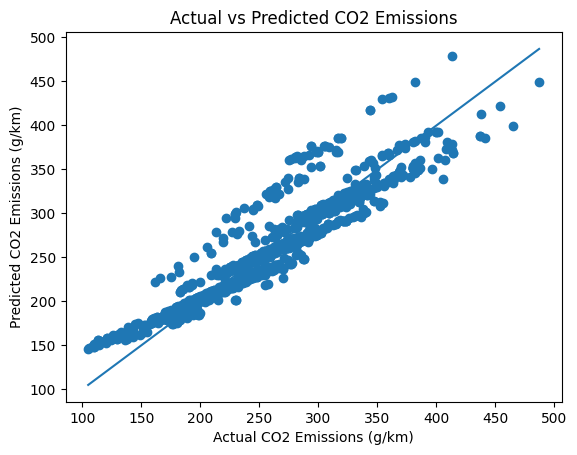

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

# Scatter plot of actual vs predicted
plt.scatter(y_test, y_pred_lr)

# Perfect prediction line (diagonal line)
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual CO2 Emissions (g/km)")
plt.ylabel("Predicted CO2 Emissions (g/km)")
plt.title("Actual vs Predicted CO2 Emissions")

plt.show()